# US Airlines Tweets

### System setup

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


## 1. Data understanding

In [4]:
# Load data
data = pd.read_csv("Data/Tweets.csv")

### 1.1 Basic understanding

In [5]:
data.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [6]:
# Show the classes of the features
print("Unique sentiment classes: ", data["airline_sentiment"].unique(), "\n")
print("Classes for negative reason: ", data["negativereason"].unique(), "\n")
print("The airlines: ", data["airline"].unique(), "\n")
print("Sentiment classes for gold...?: ", data["airline_sentiment_gold"].unique(), "\n")
print("Classes gold for negative reason: ", data["negativereason_gold"].unique(), "\n")
print("Classes gold for negative reason: ", data["tweet_location"].unique(), "\n")

Unique sentiment classes:  <StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str 

Classes for negative reason:  <StringArray>
[                          nan,                  'Bad Flight',
                  'Can't Tell',                 'Late Flight',
      'Customer Service Issue',     'Flight Booking Problems',
                'Lost Luggage', 'Flight Attendant Complaints',
            'Cancelled Flight',             'Damaged Luggage',
                   'longlines']
Length: 11, dtype: str 

The airlines:  <StringArray>
['Virgin America', 'United', 'Southwest', 'Delta', 'US Airways', 'American']
Length: 6, dtype: str 

Sentiment classes for gold...?:  <StringArray>
[nan, 'negative', 'neutral', 'positive']
Length: 4, dtype: str 

Classes gold for negative reason:  <StringArray>
[                                       nan,
 'Late Flight\nFlight Attendant Complaints',
                'Late Flight\nLost Luggage',
                              'Late Flight',
            

In [7]:
print("Shape of the data: ",data.shape, "\n") # shape of the data
print("Columns in the data: \n", data.columns, "\n") # Columnnames
print("Types of the features: \n", data.dtypes) # Data types of the features

Shape of the data:  (14640, 15) 

Columns in the data: 
 Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='str') 

Types of the features: 
 tweet_id                          int64
airline_sentiment                   str
airline_sentiment_confidence    float64
negativereason                      str
negativereason_confidence       float64
airline                             str
airline_sentiment_gold              str
name                                str
negativereason_gold                 str
retweet_count                     int64
text                                str
tweet_coord                         str
tweet_created                       str
tweet_location                      str
user_timezone                

In [8]:
# Describe the numerical features
data.describe()

,tweet_id,airline_sentiment_confidence,negativereason_confidence,retweet_count
count,1.464000e+04,14640.000000,10522.000000,14640.000000
mean,5.692184e+17,0.900169,0.638298,0.082650
std,7.791112e+14,0.162830,0.330440,0.745778
min,5.675883e+17,0.335000,0.000000,0.000000
25%,5.685592e+17,0.692300,0.360600,0.000000
50%,5.694779e+17,1.000000,0.670600,0.000000
75%,5.698905e+17,1.000000,1.000000,0.000000
max,5.703106e+17,1.000000,1.000000,44.000000


### 1.2 Data Quality

In [9]:
# missing values
data.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

In [10]:
# Duplicates
print("Amount of duplicates in the data:", data.duplicated().sum(), "\n") # 36 duplicates
data[data.duplicated()] # show rows that are duplicates

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
12040,570308309682675712,negative,1.0,Customer Service Issue,1.0,American,NaN,SweeLoTmac,NaN,0,@AmericanAir why would I even consider continu...,NaN,2015-02-24 11:44:31 -0800,NaN,Quito
12059,570305051819941889,neutral,1.0,NaN,NaN,American,NaN,Chandrafaythe,NaN,0,@AmericanAir my flight got Cancelled Flightled...,NaN,2015-02-24 11:31:34 -0800,NaN,Quito
12063,570303383782989824,neutral,1.0,NaN,NaN,American,NaN,trentgillaspie,NaN,0,.@AmericanAir just disappointed with the Fligh...,NaN,2015-02-24 11:24:57 -0800,"Austin, but often Denver",Mountain Time (US & Canada)
12066,570301929580048385,neutral,1.0,NaN,NaN,American,NaN,FinEdChat,NaN,0,@AmericanAir I did,NaN,2015-02-24 11:19:10 -0800,"Cincinnati, Ohio",Atlantic Time (Canada)
12068,570301395141836801,negative,1.0,Late Flight,1.0,American,NaN,JoBarredaV,NaN,1,@AmericanAir r u serious?? 304min #delay with ...,NaN,2015-02-24 11:17:02 -0800,Mexico City,Central Time (US & Canada)
12069,570300915418320897,negative,1.0,Cancelled Flight,1.0,American,NaN,LancasterPattie,NaN,0,@AmericanAir You are jumping the gun and Cance...,NaN,2015-02-24 11:15:08 -0800,NaN,NaN
12074,570299252141903873,positive,1.0,NaN,NaN,American,NaN,Mtts28,NaN,0,@AmericanAir This is exactly why ill be flying...,NaN,2015-02-24 11:08:32 -0800,Virginia,Eastern Time (US & Canada)
12075,570298770136674304,negative,1.0,Customer Service Issue,1.0,American,NaN,law_econ,NaN,0,@AmericanAir This doesn't address my issue. I ...,NaN,2015-02-24 11:06:37 -0800,"Newport Beach, CA",Central Time (US & Canada)
12078,570298644475346945,negative,1.0,Customer Service Issue,1.0,American,NaN,denismishin,NaN,0,@AmericanAir submitted a case to AA customer r...,NaN,2015-02-24 11:06:07 -0800,"Bellevue, WA",Eastern Time (US & Canada)
12079,570298371140939776,negative,1.0,Late Flight,1.0,American,NaN,djjohnpayne,NaN,0,@AmericanAir if by near the gate you mean sitt...,"[0.0, 0.0]",2015-02-24 11:05:01 -0800,"Las Vegas, NV",Pacific Time (US & Canada)


In [11]:
data[data["tweet_id"] == 570308309682675712] # show one of the duplicates

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
11879,570308309682675712,negative,1.0,Customer Service Issue,1.0,American,NaN,SweeLoTmac,NaN,0,@AmericanAir why would I even consider continu...,NaN,2015-02-24 11:44:31 -0800,NaN,Quito
12040,570308309682675712,negative,1.0,Customer Service Issue,1.0,American,NaN,SweeLoTmac,NaN,0,@AmericanAir why would I even consider continu...,NaN,2015-02-24 11:44:31 -0800,NaN,Quito


In [12]:
# Show some random samples to asses quality
data["text"].sample(10, random_state=8)
# see some hashtags, links, abbreviations

6046     @SouthwestAir aww thanks!! Other than that, lo...
10963    @USAirways @AmericanAir I'm in the #finalstret...
758      @united we just flew with United from AUS (Aus...
12064                                  @AmericanAir thanks
12923    @AmericanAir I still can't get through to chan...
12061    @AmericanAir your planes made me miss 2 connec...
4479     @SouthwestAir I "heart" Southwest but those co...
4933     @SouthwestAir Thanks. 436. Only a minor delay ...
5922     @SouthwestAir thanks for your attention, I've ...
6022     @SouthwestAir guess where Ashley is. She's doi...
Name: text, dtype: str

In [13]:
def show_balance(data, col_name):
    balance = pd.concat({'count': data[col_name].value_counts(),'balance': data[col_name].value_counts(normalize=True)}, axis=1)
    print(f"Class distribution for '{col_name}':\n", balance)

show_balance(data, 'airline_sentiment')

Class distribution for 'airline_sentiment':
                    count   balance
airline_sentiment                 
negative            9178  0.626913
neutral             3099  0.211680
positive            2363  0.161407


### 1.3 Exploratory Data Analysis

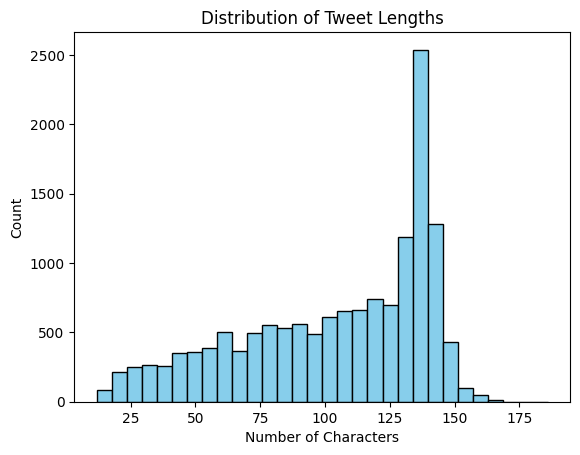

In [14]:
# Length of the tweets in characters
text_length = data["text"].str.len()

# Create the histogram
plt.hist(text_length, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Tweet Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Count')

# Save
plt.savefig('plots/text_length_histogram.png')

In [15]:
# Just an example to calculate the number of characters
t = data["text"][0]
print(t)
print(len(t))


@VirginAmerica What @dhepburn said.
35


In [16]:
# Most frequent words
# all tweets in one large string, lowercase everything, and split into words
all_words = ' '.join(data['text']).lower().split()
# Get the frequency of each word
word_freq = Counter(all_words)
word_freq_df = pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency']) # to dataframe
word_freq_df.sort_values(by="Frequency", ascending=False)

,Word,Frequency
8,to,8590
9,the,6034
12,i,5351
37,a,4461
48,for,3964
...,...,...
26831,@jlhalldc,1
26830,"play,",1
26829,answers!,1
26828,3.30pm,1


In [17]:
# Airline balance
airline_counts= data["airline"].value_counts()
airline_counts


airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

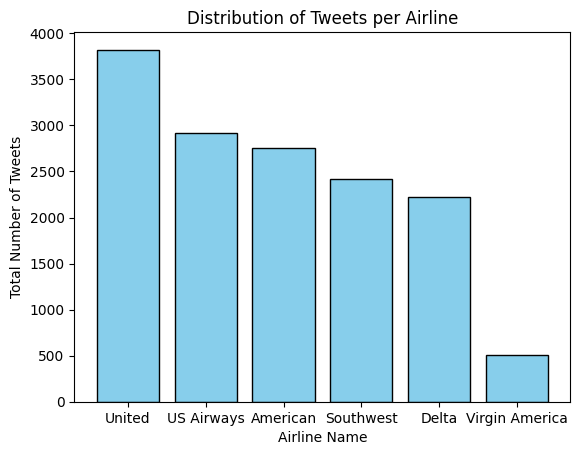

In [18]:
# Plot Airline balance
plt.bar(airline_counts.index, airline_counts.values, color='skyblue', edgecolor='black')
plt.title('Distribution of Tweets per Airline')
plt.xlabel('Airline Name')
plt.ylabel('Total Number of Tweets')

# Save
plt.savefig('plots/airline_class_balance.png')

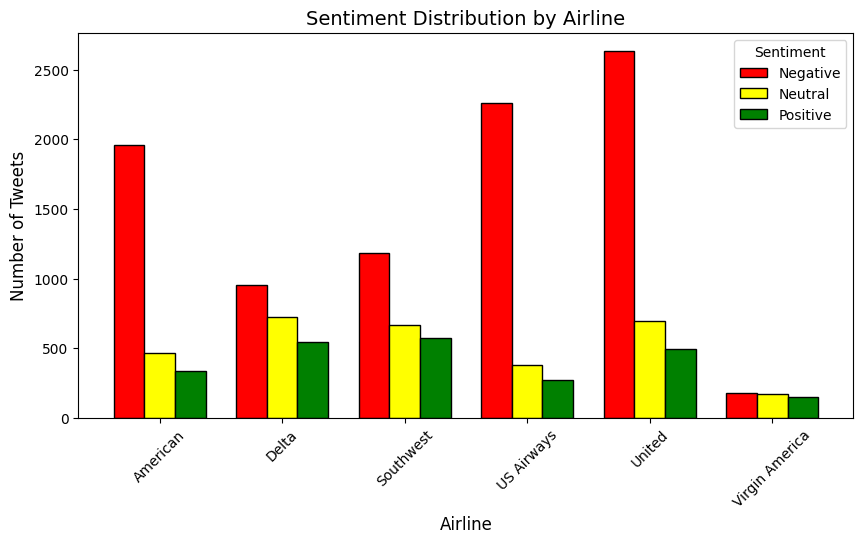

In [19]:
# Class balance per airline
# Group airline with sentiment
sentiment_data = data.groupby(['airline', 'airline_sentiment']).size().unstack(fill_value=0)

# Figure settings
plt.figure(figsize=(10, 5))
airlines = sentiment_data.index
x = np.arange(len(airlines))  # The label locations
width = 0.25

# Plot sentiment group with colors
plt.bar(x - width, sentiment_data['negative'], width, label='Negative', color='red', edgecolor='black')
plt.bar(x, sentiment_data['neutral'], width, label='Neutral', color='yellow', edgecolor='black')
plt.bar(x + width, sentiment_data['positive'], width, label='Positive', color='green', edgecolor='black')

# Figure Layout
plt.title('Sentiment Distribution by Airline', fontsize=14)
plt.xlabel('Airline', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.xticks(x, airlines, rotation=45) # Set airline names as x-axis labels
plt.legend(title='Sentiment')

# Save
plt.savefig('plots/sentiment_per_airline.png')

## 2. Data preparation

tokenization, lowercasing, handling
punctuation, and potentially removing stop words (whenever is deemed necessary and
appropriate). Students should also consider how to handle unknown words (i.e., OOV –
Out of Vocabulary) and how to manage variable-length sequences.

In [20]:
# Initial cleaning
data = data.drop_duplicates()

# Drop irrelevant columns
columns_to_drop = ['tweet_coord', 'name', 'tweet_location', 'user_timezone', 'airline']
data_clean = data.drop(columns=columns_to_drop)

print("Shape after initial cleaning:", data_clean.shape)

Shape after initial cleaning: (14604, 10)


#### Text preprocessing

In [21]:
data_clean["text_clean"] = (
    data_clean["text"]
    .str.lower()
    .str.replace(r"http\S+|www\S+|https\S+", "", regex=True) # Remove URLs
    .str.replace(r"@\w+", "", regex=True)                    # Remove @mentions
    .str.replace(r"<[^>]+>", "", regex=True)                 # Remove HTML tags
    .str.replace(r"[^\w\s]", "", regex=True)                 # Remove punctuation
    .str.replace(r"\d+", "", regex=True)                     # Remove numbers
    .str.replace(r"\b[a-z]\b", "", regex=True)               # Remove one-letter words
    .str.replace(r"\s+", " ", regex=True)                    # Remove extra whitespaces 
    .str.strip()                                             # Trim leading/trailing spaces
)

# Check the results
data_clean[["text", "text_clean"]].head()

,text,text_clean
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need to take another trip
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious enter...
4,@VirginAmerica and it's a really big bad thing...,and its really big bad thing about it


## 3. Modelling

• A baseline model using classical NLP techniques (e.g., TF-IDF + Logistic
Regression or Naive Bayes)

• A neural model such as an LSTM, CNN for text classification, or a Transformer-
based model like BERT.

In [22]:
X = data_clean["text_clean"]
y = data_clean["airline_sentiment"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Base model

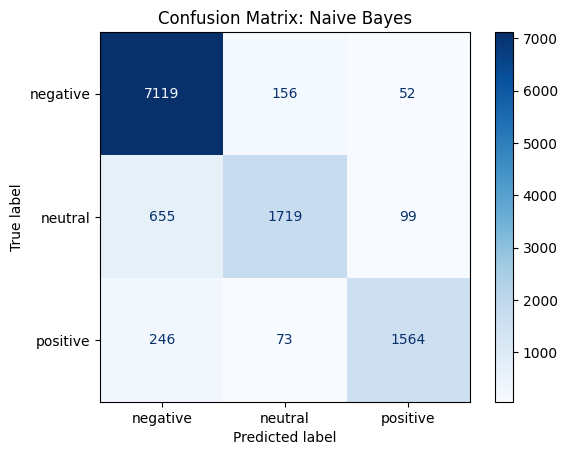

In [31]:
logit_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', MultinomialNB())
])

logit_params = {
    'tfidf__max_features': [5000, 10000, 20000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.1, 1, 10],
}

nb_params = {
    'tfidf__max_features': [5000, 10000, 20000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__alpha': [0.1, 0.5, 1.0],
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro', #very important metric as classes are imbalanced. Takes average of f1 per class. 
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

def validate_model(X_train, y_train, model_pipeline, params, name, cv_model, metrics):
    grid = GridSearchCV(model_pipeline, params, cv=cv_model, scoring=metrics, refit='f1_macro', n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)
    
    print(f"\n{name}:")
    print(f"  Best params: {grid.best_params_}")
    for metric in metrics:
        best_idx = grid.best_index_
        mean = grid.cv_results_[f'mean_test_{metric}'][best_idx]
        std = grid.cv_results_[f'std_test_{metric}'][best_idx]
        print(f"  {metric}: {mean:.4f} (+/- {std:.4f})")

    # Ff checken of dit by jullie wel werkt...
    # # Plot Confusion Matrix
    # y_pred = grid.predict(X_train)
    # cm = confusion_matrix(y_train, y_pred)
    #
    # # Explicitly create a new figure to prevent overwriting
    # plt.figure(figsize=(8, 6))
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid.classes_)
    # disp.plot(cmap='Blues', values_format='d')
    # plt.title(f'Confusion Matrix: {name}')

    plt.plot()

    return grid

logit_result = validate_model(X_train, y_train, logit_pipeline, logit_params, 'Logistic Regression', skf, metrics)
nb_result = validate_model(X_train, y_train, nb_pipeline, nb_params, 'Naive Bayes', skf, metrics)

### Neural model

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter
from sklearn.metrics import classification_report, f1_score, accuracy_score, ConfusionMatrixDisplay
import re
import itertools

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


In [23]:
MIN_FREQ = 2 #How often does the word have to occur? 


def tokenize(text):
    return text.split()


token_counter = Counter(tok for text in X_train for tok in tokenize(text))
special_tokens = ["<PAD>", "<UNK>"]
vocab = special_tokens + [tok for tok, count in token_counter.items() if count >= MIN_FREQ] # only input word in vocab if frequency is higher than min.

word2idx = {word: idx for idx, word in enumerate(vocab)} 
idx2word = {idx: word for word, idx in word2idx.items()}
label2idx = {label: idx for idx, label in enumerate(sorted(y_train.unique()))} #label negative, neutral and positive with number
idx2label = {idx: label for label, idx in label2idx.items()}

PAD_IDX = word2idx["<PAD>"]
UNK_IDX = word2idx["<UNK>"] #OOV handling: words not in vocab (rare or unseen) map to this index

def encode_token(tok):
    return word2idx.get(tok, UNK_IDX)

print(f"Vocabulary size: {len(vocab)}")

print(f"Label mapping: {label2idx}")

Vocabulary size: 5110
Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


In [24]:
def encode_dataset(texts, labels):
    encoded = []
    for text, label in zip(texts, labels):
        encoded.append({
            "input_ids": [encode_token(tok) for tok in tokenize(text)],
            "label": label2idx[label],
        })
    return encoded

def make_collate_fn(pad_idx):
    def collate_fn(batch):
        max_len = max(len(item["input_ids"]) for item in batch)
        input_ids, labels = [], []
        for item in batch:
            pad_len = max_len - len(item["input_ids"])
            input_ids.append(item["input_ids"] + [pad_idx] * pad_len)
            labels.append(item["label"])
        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
        }
    return collate_fn

BATCH_SIZE = 64
collate_fn = make_collate_fn(PAD_IDX)

X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

train_ds = encode_dataset(X_train_nn, y_train_nn)
val_ds = encode_dataset(X_val_nn, y_val_nn)
test_ds = encode_dataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

batch = next(iter(train_loader))
print("Batch shapes:")
print("  input_ids:", tuple(batch["input_ids"].shape))
print("  labels:", tuple(batch["labels"].shape))

Batch shapes:
  input_ids: (64, 26)
  labels: (64,)


### Initialise LSTM

In [30]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_labels, pad_idx, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.encoder = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim // 2,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_labels)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        x, _ = self.encoder(x)
        
        mask = (input_ids != PAD_IDX).unsqueeze(-1).float() #need one vector for the whole tweet instead, so take average of all non-padded outputs. 1 for real tokens, 0 for padding
        x = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        
        x = self.dropout(x)
        return self.classifier(x)

In [31]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * input_ids.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    y_true, y_pred = [], []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids)
        loss = criterion(logits, labels)
        total_loss += loss.item() * input_ids.size(0)

        y_true.extend(labels.cpu().tolist())
        y_pred.extend(logits.argmax(dim=-1).cpu().tolist())

    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "y_true": y_true,
        "y_pred": y_pred,
    }

#### Hyperparameter tuning

In [ ]:
param_grid = {
    'embed_dim': [50, 100],
    'hidden_dim': [64, 128],
    'lr': [1e-3, 5e-4],
    'dropout': [0.3, 0.5],
}

EPOCHS = 10
best_f1 = 0
best_params = None
best_model_state = None

combinations = list(itertools.product(*param_grid.values()))
print(f"Total combinations: {len(combinations)}\n")

class_counts = y_train_nn.value_counts().sort_index()
class_weights = 1.0 / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights / class_weights.sum()

for embed_dim, hidden_dim, lr, dropout in combinations:
    model = BiLSTMClassifier(
        vocab_size=len(vocab),
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        num_labels=len(label2idx),
        pad_idx=PAD_IDX,
        dropout=dropout,
    ).to(device)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(1, EPOCHS + 1):
        train_one_epoch(model, train_loader, optimiser, criterion)
    
    val_metrics = evaluate_model(model, val_loader, criterion)
    macro_f1 = val_metrics['macro_f1']
    
    print(f"embed={embed_dim}, hidden={hidden_dim}, lr={lr}, dropout={dropout} | val Macro-F1: {macro_f1:.4f}")
    
    if macro_f1 > best_f1:
        best_f1 = macro_f1
        best_params = {'embed_dim': embed_dim, 'hidden_dim': hidden_dim, 'lr': lr, 'dropout': dropout}
        best_model_state = model.state_dict()

print(f"\nBest params: {best_params}")
print(f"Best val F1 macro: {best_f1:.4f}")

Total combinations: 16

embed=50, hidden=64, lr=0.001, dropout=0.3 | val F1: 0.6972
embed=50, hidden=64, lr=0.001, dropout=0.5 | val F1: 0.7076
embed=50, hidden=64, lr=0.0005, dropout=0.3 | val F1: 0.6846
embed=50, hidden=64, lr=0.0005, dropout=0.5 | val F1: 0.7167
embed=50, hidden=128, lr=0.001, dropout=0.3 | val F1: 0.6914
embed=50, hidden=128, lr=0.001, dropout=0.5 | val F1: 0.7090
embed=50, hidden=128, lr=0.0005, dropout=0.3 | val F1: 0.6995
embed=50, hidden=128, lr=0.0005, dropout=0.5 | val F1: 0.6965
embed=100, hidden=64, lr=0.001, dropout=0.3 | val F1: 0.6895
embed=100, hidden=64, lr=0.001, dropout=0.5 | val F1: 0.7058
embed=100, hidden=64, lr=0.0005, dropout=0.3 | val F1: 0.7132
embed=100, hidden=64, lr=0.0005, dropout=0.5 | val F1: 0.7048
embed=100, hidden=128, lr=0.001, dropout=0.3 | val F1: 0.7105
embed=100, hidden=128, lr=0.001, dropout=0.5 | val F1: 0.7060
embed=100, hidden=128, lr=0.0005, dropout=0.3 | val F1: 0.6874
embed=100, hidden=128, lr=0.0005, dropout=0.5 | val F1:

#### Final evaluation

Test F1 macro: 0.6960

Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.80      0.84      1832
     neutral       0.53      0.68      0.60       618
    positive       0.67      0.64      0.66       471

    accuracy                           0.75      2921
   macro avg       0.69      0.71      0.70      2921
weighted avg       0.77      0.75      0.76      2921



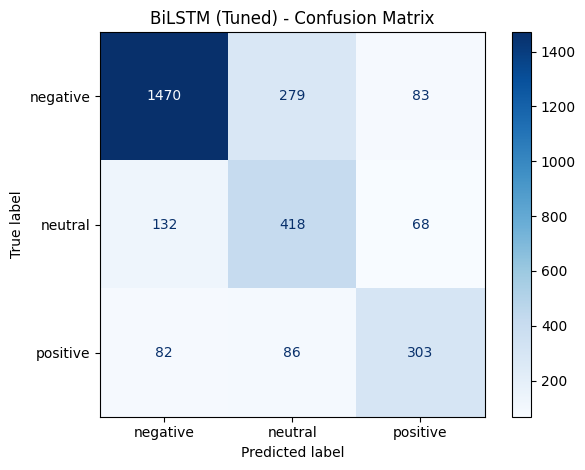

In [33]:
best_model = BiLSTMClassifier(
    vocab_size=len(vocab),
    embed_dim=best_params['embed_dim'],
    hidden_dim=best_params['hidden_dim'],
    num_labels=len(label2idx),
    pad_idx=PAD_IDX,
    dropout=best_params['dropout']).to(device)

best_model.load_state_dict(best_model_state)

test_metrics = evaluate_model(best_model, test_loader, criterion)
print(f"Test F1 macro: {test_metrics['macro_f1']:.4f}")

print("\nClassification Report:")
print(classification_report(test_metrics["y_true"], test_metrics["y_pred"], target_names=[idx2label[i] for i in range(len(label2idx))]))

ConfusionMatrixDisplay.from_predictions(
    test_metrics["y_true"], test_metrics["y_pred"],
    display_labels=[idx2label[i] for i in range(len(label2idx))], cmap='Blues'
)
plt.title("BiLSTM (Tuned) - Confusion Matrix")
plt.tight_layout()
plt.show()

## 4. Evaluation

The models must be evaluated using metrics such as accuracy, precision, recall, and F1-
score. Students should also include a confusion matrix and perform a qualitative analysis
of misclassified examples.